## What are the most in demand skills for the Top 3 Popular Data roles? ##

#### Methodology ####

1. Cleanup skill column
2. Calculate skill count based on `job_title_short`
3. Calculate skill percentage
4. Plot final findings

In [2]:
# importing libraries
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\rpran\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_exploded = df.explode('job_skills')
df_group = df_exploded.groupby(['job_title_short','job_skills'])['job_skills'].agg('count').reset_index(name='skill_count').sort_values(by='skill_count', ascending=False)
df_group

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


In [4]:
df_job_count = df['job_title_short'].value_counts().reset_index(name='total_count')
df_job_count

,job_title_short,total_count
0,Data Analyst,196075
1,Data Engineer,186241
2,Data Scientist,172286
3,Business Analyst,49063
4,Software Engineer,44929
5,Senior Data Engineer,44563
6,Senior Data Scientist,36957
7,Senior Data Analyst,29216
8,Machine Learning Engineer,14080
9,Cloud Engineer,12331


In [6]:
df_perc = pd.merge(df_group, df_job_count, on='job_title_short', how='left')
df_perc['skill_percentage'] = (df_perc['skill_count'] / df_perc['total_count']) * 100
df_perc

,job_title_short,job_skills,skill_count,total_count,skill_percentage
0,Data Scientist,python,113711,172286,66.001300
1,Data Engineer,sql,113130,186241,60.743875
2,Data Engineer,python,108022,186241,58.001192
3,Data Analyst,sql,92428,196075,47.139105
4,Data Scientist,sql,78982,172286,45.843539
...,...,...,...,...,...
2251,Data Analyst,chainer,1,196075,0.000510
2252,Cloud Engineer,wrike,1,12331,0.008110
2253,Cloud Engineer,theano,1,12331,0.008110
2254,Business Analyst,chainer,1,49063,0.002038


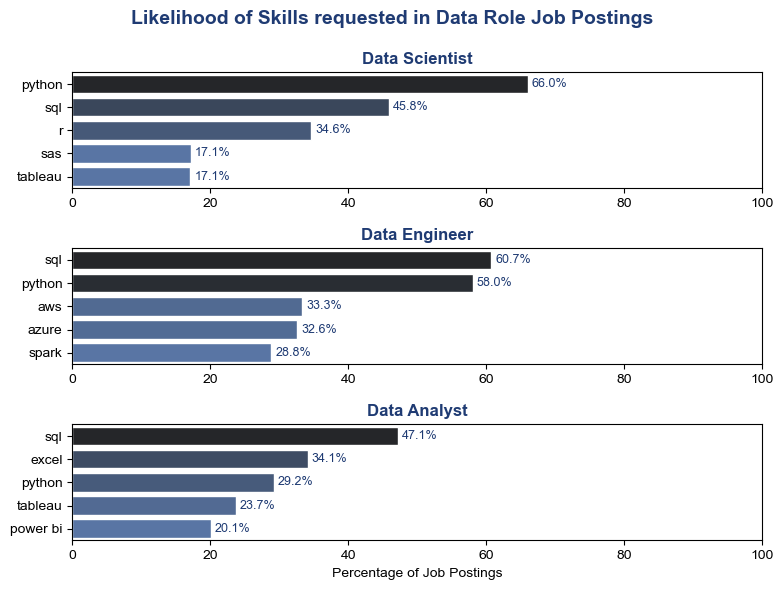

In [7]:
job_titles = ['Data Scientist','Data Engineer','Data Analyst']

fig,ax = plt.subplots(3,1, figsize=(8,6))

for i, job_title in enumerate(job_titles):
    df_plot = df_perc[df_perc['job_title_short'] == job_title].head(5)
    sns.set_theme(style='ticks')
    sns.barplot(data = df_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue='skill_percentage', palette='dark:b_r', legend= False)
    # sns.despine()
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].set_title(job_title, fontweight='bold', color='#1f3b73')
    ax[i].set_xlim(0,100)
    for container in ax[i].containers:
        ax[i].bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontsize=9, color='#1f3b73')

fig.suptitle('Likelihood of Skills requested in Data Role Job Postings',fontsize=14, color='#1f3b73', fontweight='bold')
ax[-1].set_xlabel('Percentage of Job Postings')

fig.tight_layout()
plt.show()